In [1]:
import simpy
import random
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass

print("Library berhasil diimport")


Library berhasil diimport


In [2]:
@dataclass
class Config:

    # jumlah sistem
    JUMLAH_MEJA: int = 60
    ORANG_PER_MEJA: int = 3
    TOTAL_OMPRENG: int = 60*3
    
    # jumlah petugas
    PETUGAS_LAUK: int = 3
    PETUGAS_ANGKUT: int = 2
    PETUGAS_NASI: int = 2

    # waktu proses (detik)
    LAUK_MIN: float = 30
    LAUK_MAX: float = 60
    
    ANGKUT_MIN: float = 20
    ANGKUT_MAX: float = 60
    
    NASI_MIN: float = 30
    NASI_MAX: float = 60

    # kapasitas angkut
    MIN_ANGKUT: int = 4
    MAX_ANGKUT: int = 7

    # waktu mulai
    START_HOUR: int = 7
    START_MINUTE: int = 0

    RANDOM_SEED: int = 42

print("Konfigurasi siap")


Konfigurasi siap


In [3]:
class SimulasiPiketKantin:

    def __init__(self, config: Config):

        self.config = config
        self.env = simpy.Environment()

        # resource petugas
        self.lauk = simpy.Resource(self.env, capacity=config.PETUGAS_LAUK)
        self.angkut = simpy.Resource(self.env, capacity=config.PETUGAS_ANGKUT)
        self.nasi = simpy.Resource(self.env, capacity=config.PETUGAS_NASI)

        # statistik
        self.data = []

        # waktu mulai
        self.start_time = datetime(2024,1,1,
                                   config.START_HOUR,
                                   config.START_MINUTE)

        random.seed(config.RANDOM_SEED)
        np.random.seed(config.RANDOM_SEED)


    # =====================
    # GENERATOR WAKTU
    # =====================
    def waktu_lauk(self):
        return random.uniform(self.config.LAUK_MIN,
                              self.config.LAUK_MAX)

    def waktu_angkut(self):
        return random.uniform(self.config.ANGKUT_MIN,
                              self.config.ANGKUT_MAX)

    def waktu_nasi(self):
        return random.uniform(self.config.NASI_MIN,
                              self.config.NASI_MAX)


    # =====================
    # PROSES OMPreng
    # =====================
    def proses_ompreng(self, id):

        datang = self.env.now

        # proses lauk
        with self.lauk.request() as req:
            yield req
            yield self.env.timeout(self.waktu_lauk())

        # proses angkut
        with self.angkut.request() as req:
            yield req
            yield self.env.timeout(self.waktu_angkut())

        # proses nasi
        with self.nasi.request() as req:
            yield req
            yield self.env.timeout(self.waktu_nasi())

        selesai = self.env.now

        self.data.append({
            "id": id,
            "datang": datang,
            "selesai": selesai,
            "durasi": selesai - datang,
            "jam_selesai": self.start_time + timedelta(seconds=selesai)
        })


    # =====================
    # GENERATE OMPreng
    # =====================
    def generate(self):

        for i in range(self.config.TOTAL_OMPRENG):
            self.env.process(self.proses_ompreng(i))
            yield self.env.timeout(0.1)


    # =====================
    # RUN SIMULASI
    # =====================
    def run(self):

        self.env.process(self.generate())
        self.env.run()

        df = pd.DataFrame(self.data)

        hasil = {
            "total": len(df),
            "waktu_selesai": df["selesai"].max(),
            "jam_selesai": self.start_time + timedelta(seconds=df["selesai"].max()),
            "rata_durasi": df["durasi"].mean(),
            "maks": df["durasi"].max(),
            "min": df["durasi"].min()
        }

        return hasil, df

print("Model simulasi siap")


Model simulasi siap


In [4]:
def visualize(df):

    fig, axes = plt.subplots(1,2, figsize=(12,5))

    # histogram durasi
    axes[0].hist(df["durasi"], bins=30)
    axes[0].set_title("Distribusi Durasi Proses")
    axes[0].set_xlabel("Detik")
    axes[0].set_ylabel("Frekuensi")

    # timeline
    axes[1].scatter(df["datang"], df["id"], s=5, label="Mulai")
    axes[1].scatter(df["selesai"], df["id"], s=5, label="Selesai")
    axes[1].legend()
    axes[1].set_title("Timeline Proses")

    plt.tight_layout()
    plt.show()

print("Visualisasi siap")


Visualisasi siap


=== HASIL SIMULASI ===
Total Ompreng: 180
Durasi Total: 67.44 menit
Jam Selesai: 08:07:26.376171

Statistik Durasi
Rata-rata: 2088.78 detik
Max: 4028.48
Min: 102.34


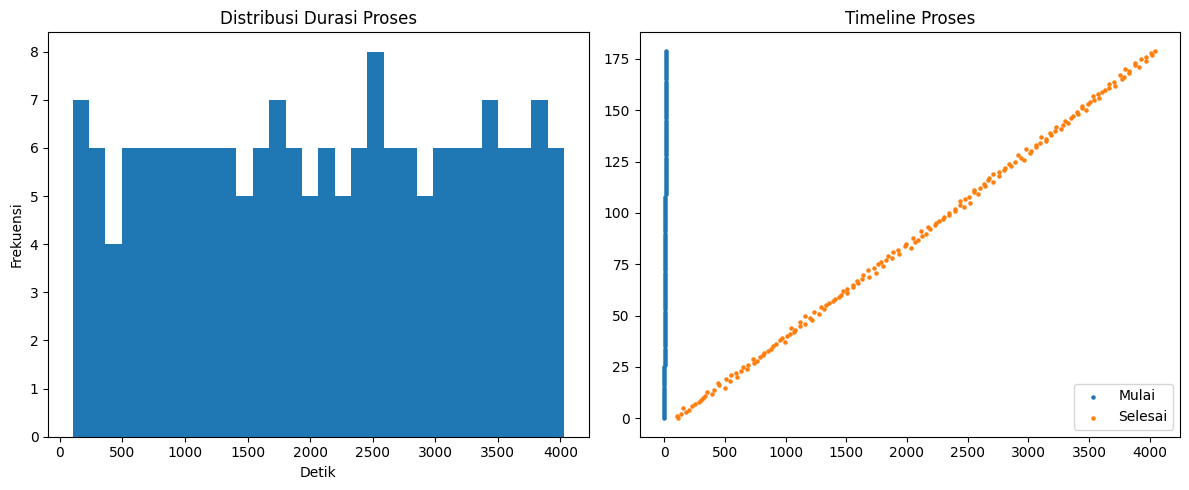

In [5]:
config = Config()

model = SimulasiPiketKantin(config)

hasil, df = model.run()

print("=== HASIL SIMULASI ===")
print("Total Ompreng:", hasil["total"])
print("Durasi Total:", round(hasil["waktu_selesai"]/60,2),"menit")
print("Jam Selesai:", hasil["jam_selesai"].time())

print("\nStatistik Durasi")
print("Rata-rata:", round(hasil["rata_durasi"],2),"detik")
print("Max:", round(hasil["maks"],2))
print("Min:", round(hasil["min"],2))

visualize(df)
